In [46]:
import os
import geopandas as gpd
import requests
import pandas as pd
import folium
import matplotlib.pyplot as plt

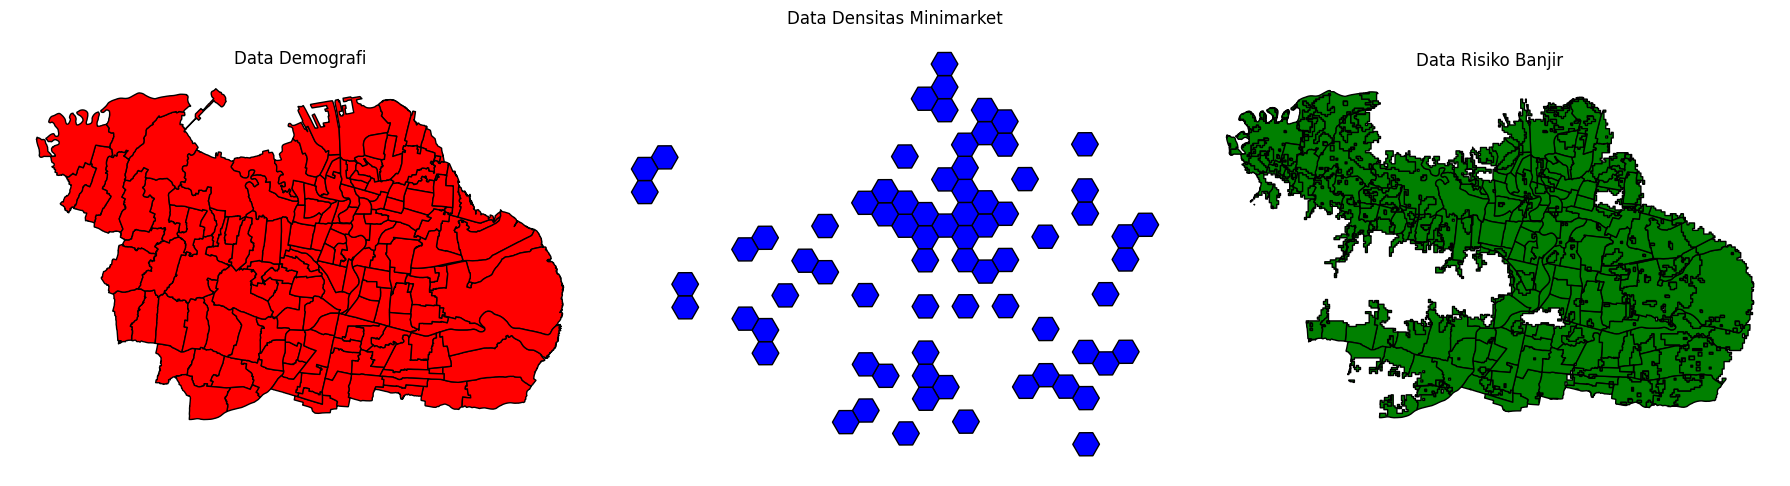

In [47]:
# URL API
urls = { 
    "Demografi": "https://geoserver.mapid.io/layers_new/get_layer?api_key=a307381cb02646f097a90da25d515fe0&layer_id=68af210cabcfc44262fbd37e&project_id=6895f5ff4f6ff4f55ccedfd0&limit=10000",
    "Densitas Minimarket": "https://geoserver.mapid.io/layers_new/get_layer?api_key=a307381cb02646f097a90da25d515fe0&layer_id=68aef6f3abcfc44262fb8dd8&project_id=6895f5ff4f6ff4f55ccedfd0&limit=10000",
    "Risiko Banjir": "https://geoserver.mapid.io/layers_new/get_layer?api_key=a307381cb02646f097a90da25d515fe0&layer_id=68add2c0b2fcc5561a310d91&project_id=6895f5ff4f6ff4f55ccedfd0&limit=10000"
}


# Fungsi ambil data API
def get_data(url, layer_name):
    response = requests.get(url)
    if response.status_code == 200:
        geojson_data = response.json()
        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])

        # Menambahkan kolom SKOR sesuai layer
        if layer_name == "Demografi":
            gdf["SKOR_DEMOGRAFI"] = gdf.get("KELAS_DEMOGRAFI", "").str.upper().map({"RENDAH": 1, "SEDANG": 2, "TINGGI": 3}).fillna(0)
        elif layer_name == "Densitas Minimarket":
            gdf["SKOR_DENSITAS"] = gdf.get("NUMPOINTS", "").str.upper().map({"RENDAH": 3, "SEDANG": 2, "TINGGI": 1}).fillna(0)
        elif layer_name == "Risiko Banjir":
            gdf["SKOR_BANJIR"] = gdf.get("KELAS_RISIKO", "").str.upper().map({"RENDAH": 1, "SEDANG": 2, "TINGGI": 3}).fillna(0)

        return gdf
    else:
        print(f"Gagal mengambil data {layer_name}, status code: {response.status_code}")
        return None

# Ambil semua layer
gdf_demografi = get_data(urls["Demografi"], "KELAS_DEMOGRAFI")
gdf_densitas = get_data(urls["Densitas Minimarket"], "NUMPOINTS")
gdf_banjir = get_data(urls["Risiko Banjir"], "Risiko Banjir")

# Fungsi visualisasi
def visualisasi_data(gdfs):
    fig, axes = plt.subplots(1, len(gdfs), figsize=(18, 6))
    color_map = ['red', 'blue', 'green']
    
    for ax, (name, gdf), color in zip(axes, gdfs.items(), color_map):
        if gdf is not None:
            gdf.plot(ax=ax, color=color, edgecolor='black')
            ax.set_title(name)
            ax.set_axis_off()
        else:
            ax.set_title(f"{name} (Data kosong)")
            ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

# Menampilkan visualisasi
visualisasi_data({
    "Data Demografi": gdf_demografi, 
    "Data Densitas Minimarket": gdf_densitas, 
    "Data Risiko Banjir": gdf_banjir
})




In [52]:
import geopandas as gpd
import pandas as pd
import numpy as np

# Pastikan nilai null ditangani sebelum overlay
for gdf, col in [(gdf_demografi, "SKOR_DEMOGRAFI"),
                 (gdf_densitas, "SKOR_DENSITAS"),
                 (gdf_banjir, "SKOR_BANJIR")]:
    if col in gdf.columns:
        gdf[col] = gdf[col].fillna(0)
    # perbaiki geometri
    gdf["geometry"] = gdf["geometry"].buffer(0)

# Analisis Intersect / Overlay
intersection_gdf = gdf_demografi
if not gdf_densitas.empty:
    intersection_gdf = gpd.overlay(intersection_gdf, gdf_densitas, how="intersection", keep_geom_type=False)
if not gdf_banjir.empty:
    intersection_gdf = gpd.overlay(intersection_gdf, gdf_banjir, how="intersection", keep_geom_type=False)

# Fix geometry hasil overlay
intersection_gdf["geometry"] = intersection_gdf["geometry"].buffer(0)


# Pastikan semua skor ada
for col in ["SKOR_DEMOGRAFI", "SKOR_DENSITAS", "SKOR_BANJIR"]:
    if col not in intersection_gdf.columns:
        intersection_gdf[col] = 0
    intersection_gdf[col] = intersection_gdf[col].fillna(0)

# Hitung skor total
intersection_gdf["SKOR_TOTAL"] = (
    intersection_gdf["SKOR_DEMOGRAFI"] +
    intersection_gdf["SKOR_DENSITAS"] +
    intersection_gdf["SKOR_BANJIR"]
)

# Buat klasifikasi (0–3 rendah, 4–6 sedang, 7–9 tinggi)
intersection_gdf["KESESUAIAN"] = pd.cut(
    intersection_gdf["SKOR_TOTAL"],
    bins=[-1, 3, 6, 9],   # -1 agar 0 masuk
    labels=["RENDAH", "SEDANG", "TINGGI"]
)

# Output
print(intersection_gdf[["SKOR_DEMOGRAFI", "SKOR_DENSITAS", "SKOR_BANJIR", "SKOR_TOTAL", "KESESUAIAN"]].head(10))





   SKOR_DEMOGRAFI  SKOR_DENSITAS  SKOR_BANJIR  SKOR_TOTAL KESESUAIAN
0               0              0            3           3     RENDAH
1               0              0            3           3     RENDAH
2               0              0            3           3     RENDAH
3               0              0            3           3     RENDAH
4               0              0            2           2     RENDAH
5               0              0            3           3     RENDAH
6               0              0            3           3     RENDAH
7               0              0            3           3     RENDAH
8               0              0            3           3     RENDAH
9               0              0            3           3     RENDAH


In [50]:
# Simpan semua hasil ke GeoJSON
import os

# --- Direktori output ---
output_dir = r"D:\Mapid\Python\TASK_WEBGIS_ACADEMY"
os.makedirs(output_dir, exist_ok=True)

# Ambil Data Polygon & MultiPolygon 
intersection_gdf_polygons = intersection_gdf[
    intersection_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy()


# --- Perbaiki geometri tidak valid ---

intersection_gdf_polygons["geometry"] = intersection_gdf_polygons["geometry"].apply(lambda x: x.make_valid()if not x.is_valid else x)



# --- Simpan hasil intersection ---
intersection_gdf_polygons.to_file(os.path.join(output_dir, "Hasil_intersect.geojson"), driver="GeoJSON")

print(f"Data berhasil disimpan di: {output_dir}")


d:\Mapid\Python\WEBGIS_ACADEMY\Lib\site-packages\pyogrio\geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Data berhasil disimpan di: D:\Mapid\Python\TASK_WEBGIS_ACADEMY
